# IMporting libraries and files

In [28]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [2]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import *
from optimisers import *


# Importing the sequence


In [3]:
from elements import install_septa
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
line.insert_element("TECA.exit", xt.Marker(), at_s = 4020.8939 + TECS.length)

#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )

line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']

#line.cycle("TECA.entry", inplace=True)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4603 [00:00<?, ?it/s]

In [4]:
# Get the positions of the TECA and COLLIMATORS markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760_entry']
tcsm_position = line.get_table()['s', 'tcsm.51932.']

In [5]:
print_optics_features(line)

22.130000000065145
22.180000000051958
D term / B term = 3.31
sigma_x max = 10.468444860741442 mm
sigma_y max = 1.1036200168605912 mm
D term / B term = 3.31
sigma_x max = 0.010468444860741442 m
sigma_y max = 0.001103620016860591 m
Phase advance Teca - Tpst: -7.39
Phase advance Teca - Tcsm: 3.83
Phase advance Tpst - Tcsm: 11.22


## Matching the tunes

In [6]:
#tune = 22.91
tune = 24.39

In [7]:
optTune = match_tunes(line, tune, tune + 0.05)
optChromaticity = match_chromaticity(line, tune, tune + 0.05)

optTune.step(10)
optTune.target_status()
optTune.vary_status()

# CHanging the chromaticity afterwards
optChromaticity.step(10)

optChromaticity.target_status()
optChromaticity.vary_status() 

line.discard_tracker()


                                             
Optimize - start penalty: 31.96         
Matching: model call n. 20               
Optimize - end penalty:  4.68438e-05
Target status:                           
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True   2.94776e-06         24.39         24.39 'qx', val=24.39, tol=1e-05, weight=10
1  ON    qy     True   3.64063e-06         24.44         24.44 'qy', val=24.44, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqf          None             0.013649 None            0.0125751         1e-07             1
1  ON        OK  kqd          None           -0.0136523 None           -0.0125777         1e-07             1
2  ON        OK  qph_setvalue None         -2.20676e-14 None                    0        0.0001             1
3  ON        OK  qp

In [8]:
tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')



# Find apertures tha block the particles and open them

In [9]:
blocking_elements = open_blocking_apertures(line, TECA, deltaP_P)

The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21774_aper (index 1117) on turn 0
Adjusting ap.up.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21774_aper (index 1122) on turn 0
Adjusting ap.do.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21779_aper (index 1125) on turn 0
Adjusting ap.up.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21779_aper (index 1130) on turn 0
Adjusting ap.do.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21794_aper (index 1133) on turn 0
Adjusting ap.up.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channele

In [10]:
import elements 
import importlib
importlib.reload(elements)

remove_ZS_apertures(line)
remove_inner_sideLimits_closeTECA(line)

Opening aperture for element: ap.up.zs21633_aper
Element ap.up.zs21633 does not have adjustable apertures.
Element drift_zs.21633..1..0 does not have adjustable apertures.
Element zs21633.entry.p1mm does not have adjustable apertures.
Element drift_zs.21633..1..1 does not have adjustable apertures.
Element zs.21633 does not have adjustable apertures.
Element drift_zs.21633..2 does not have adjustable apertures.
Opening aperture for element: ap.do.zs21633_aper
Element ap.do.zs21633 does not have adjustable apertures.
Element drift_458 does not have adjustable apertures.
Element drift_zs.21639..1 does not have adjustable apertures.
Element zs.21639 does not have adjustable apertures.
Element drift_zs.21639..2 does not have adjustable apertures.
Element drift_459 does not have adjustable apertures.
Opening aperture for element: ap.up.zs21655_aper
Element ap.up.zs21655 does not have adjustable apertures.
Element drift_zs.21655..1 does not have adjustable apertures.
Element zs.21655 does no

In [11]:
save_df_Limit_elements_features(line)

      Position         Element Name    max_x    min_x
0     445.9241        qe.11402_aper  0.07600 -0.07600
1     543.9610        qd.11710_aper  0.04150 -0.04150
2     548.3640      mdhw.11732_aper  0.07600 -0.07600
3     552.1253      mdhw.11737_aper  0.07600 -0.07600
4     553.1843      mdhw.11738_aper  0.07600 -0.07600
..         ...                  ...      ...      ...
102  6349.1332  ap.do.mse61852_aper  0.06582 -0.06582
103  6349.9872  ap.up.mse61857_aper  0.06850 -0.06850
104  6352.3672  ap.do.mse61857_aper  0.07635 -0.07635
105  6353.2212  ap.up.mse61872_aper  0.08024 -0.08024
106  6355.6012  ap.do.mse61872_aper  0.09100 -0.09100

[107 rows x 4 columns]


,Position,Element Name,max_x,min_x
0,445.9241,qe.11402_aper,0.07600,-0.07600
1,543.9610,qd.11710_aper,0.04150,-0.04150
2,548.3640,mdhw.11732_aper,0.07600,-0.07600
3,552.1253,mdhw.11737_aper,0.07600,-0.07600
4,553.1843,mdhw.11738_aper,0.07600,-0.07600
...,...,...,...,...
102,6349.1332,ap.do.mse61852_aper,0.06582,-0.06582
103,6349.9872,ap.up.mse61857_aper,0.06850,-0.06850
104,6352.3672,ap.do.mse61857_aper,0.07635,-0.07635
105,6353.2212,ap.up.mse61872_aper,0.08024,-0.08024


In [12]:
# Save the line with the current optics into a JSON file
line.to_json("../database/lhc_q24.json")

# Adjusting the knobs

In [13]:
import optimisers as op
import importlib
importlib.reload(op)

# Define the target x and px values
#x_target = line['tpst.21760_entry.sep'].interaction_process.blade_position 
#px_target = recordNONCH.px[np.where(recordNONCH.s == tpst_position)[0][0]]
px_target = 1e-4
x_target = 0.0394 * 1.77  # This is the position of the TPST blade times a factor

# Adjust the horizontal bump for the extraction
adjustBumpLSS2 = op.horizontal_bumpLSS2(line, x_target * 0.5, px_target)

adjustBumpLSS2.log()

adjustBumpLSS2.step(10)
adjustBumpLSS2.target_status()
adjustBumpLSS2.vary_status()
knobs_after_matchLSS2 = adjustBumpLSS2.get_knob_values()
knobs_before_matchLSS2 = adjustBumpLSS2.get_knob_values(iteration=0)



# Adjust the horizontal bump for the TECA
adjustBumpLSS4 = op.horizontal_bumpLSS4(line)

adjustBumpLSS4.log()

adjustBumpLSS4.step(10)
adjustBumpLSS4.target_status()
adjustBumpLSS4.vary_status()
knobs_after_matchLSS4 = adjustBumpLSS4.get_knob_values()
knobs_before_matchLSS4 = adjustBumpLSS4.get_knob_values(iteration=0)

                                             
Optimize - start penalty: 0.3488        
Matching: model call n. 19               
Optimize - end penalty:  6.80571e-15
                                             
Optimize - start penalty: 6.806e-15      
Matching: model call n. 22               
Optimize - end penalty:  6.80571e-15
Target status:                           
id state tag                 tol_met       residue   current_val    target_val description                                 
0  ON    START_x                True             0             0             0 ('x', 'mpsh.21202'), val=0, tol=1e-09, w ...
1  ON    START_px               True             0             0             0 ('px', 'mpsh.21202'), val=0, tol=1e-09,  ...
2  ON    tpst.21760_entry_x     True     3.747e-16      0.034869      0.034869 ('x', 'tpst.21760_entry'), val=0.034869, ...
3  ON    tpst.21760_entry_px    True   2.09658e-17        0.0001        0.0001 ('px', 'tpst.21760_entry'), val=0.0001,  ...
4  ON

In [14]:
print("Extraction Bump values after the matching:")
print(knobs_after_matchLSS2)
print("Extraction Bump values before the matching:")
print(knobs_before_matchLSS2)

Extraction Bump values after the matching:
{'kmpsh21202': np.float64(-0.00010193968177021304), 'kmplh21431': np.float64(0.0007840655869879867), 'kmplh21995': np.float64(0.0006448110676721108), 'kmplh22195': np.float64(-0.0006547361766928754)}
Extraction Bump values before the matching:
{'kmpsh21202': 0.0, 'kmplh21431': 0.0, 'kmplh21995': 0.0, 'kmplh22195': 0.0}


In [15]:
print("TECA Bump values after the matching:")
print(knobs_after_matchLSS4)
print("TECA Bump values before the matching:")
print(knobs_before_matchLSS4)

TECA Bump values after the matching:
{'kmpsh41402': np.float64(-0.00032783461757712924), 'kmplh41658': np.float64(-0.0007677332532493286), 'kmplh41994': np.float64(-0.0006865679917603398), 'kmpsh42198': np.float64(-3.132362535553693e-05)}
TECA Bump values before the matching:
{'kmpsh41402': 0.0, 'kmplh41658': 0.0, 'kmplh41994': 0.0, 'kmpsh42198': 0.0}


# Installing the septa to extract the particles

In [16]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)

In [17]:
print(septa_names_with_apertures)

['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']


# Plotting optical functions at injection TT10

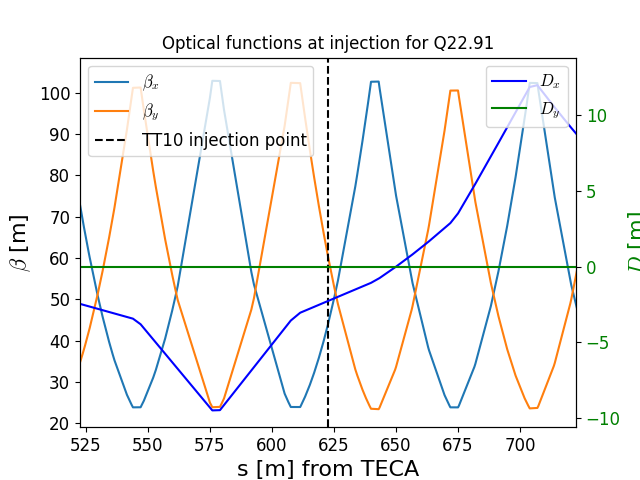

In [18]:
# Get the position of the element mkp.11955
mkp_position = line.get_table()['s', 'mkp.11955']

# Define the range around the element
x_range = (mkp_position - 100, mkp_position + 100)

# Plot the Twiss parameters in the specified range
fig, ax = plt.subplots()
ax.plot(tw['s'], tw['betx'], label=r'$\beta_x$')
ax.plot(tw['s'], tw['bety'], label=r'$\beta_y$')
ax2 = ax.twinx()
ax2.plot(tw['s'], tw['dx'], 'b-', label=r'$D_x$')
ax2.plot(tw['s'], tw['dy'], 'g-', label=r'$D_y$')
ax2.set_ylabel(r'$D$ [m]', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.legend(loc='upper right')
ax.axvline(mkp_position, color='k', linestyle='--', label='TT10 injection point')
ax.set_xlim(x_range)
ax.set_xlabel('s [m] from TECA')
ax.set_ylabel(r'$\beta$ [m]')
ax.set_title("Optical functions at injection for Q22.91")
ax.legend(loc='upper left')
plt.show()
ax.grid(True)


# Save positions and re-track particles and plots

In [19]:
df_elements = save_df_Limit_elements_features(line)

      Position         Element Name    max_x    min_x
0     445.9241        qe.11402_aper  0.07600 -0.07600
1     543.9610        qd.11710_aper  0.04150 -0.04150
2     548.3640      mdhw.11732_aper  0.07600 -0.07600
3     552.1253      mdhw.11737_aper  0.07600 -0.07600
4     553.1843      mdhw.11738_aper  0.07600 -0.07600
..         ...                  ...      ...      ...
102  6349.1332  ap.do.mse61852_aper  0.06582 -0.06582
103  6349.9872  ap.up.mse61857_aper  0.06850 -0.06850
104  6352.3672  ap.do.mse61857_aper  0.07635 -0.07635
105  6353.2212  ap.up.mse61872_aper  0.08024 -0.08024
106  6355.6012  ap.do.mse61872_aper  0.09100 -0.09100

[107 rows x 4 columns]


# Tracking a realistic beam

In [20]:
n_part = 100



x_norm   = np.random.normal(loc = 0, scale = - TECA.jaw, size=n_part)
px_norm =  np.random.normal(loc = 0, scale = 75e-6, size=n_part)  # in between being channeled and not
#x_norm  = TECA.jaw * np.ones(n_part)
#px_norm = TECA.tilt * np.ones(n_part)
y_norm, py_norm = np.zeros(n_part), np.zeros(n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * deltaP_P

line.build_tracker()

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles_init = particles.copy()
#tw_lss2 = tw.rows['TECA.entry':'_end_point']

tw_lss2 = tw.rows[:]


The line has collective elements.
In the twiss computation collective elements are replaced by drifts


In [21]:
# monitor particles at all unique positions between mba.21390_exit and qda.21910_exit
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
#tw_lss2_df = tw_lss2_df.loc['qd.20910':'qda.21910'] 
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

line.discard_tracker()

def set_monitor(row):
    monitor = xt.LastTurnsMonitor(n_last_turns=6, num_particles=particles._capacity, every_n_turns=1)
    line.insert_element(name=row.name+'_monitor', element=monitor, index=row.name)
    return monitor
tw_lss2_df['monitors'] = tw_lss2_df.apply(set_monitor, axis=1)
tw_lss2_df['i_monitor'] = np.arange(len(tw_lss2_df))    

# Inserting the crystals 

In [22]:
line.discard_tracker()
line.insert_element("extraction.crystal.TECS", TECS, at_s=line.get_table()['s', 'tecs.21602'] )
line.insert_element("extraction.crystal.TECA", TECA, at_s = line.get_table()['s', 'TECA.entry'] )

Slicing line:   0%|          | 0/8697 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/8698 [00:00<?, ?it/s]

<Line  at 4748432528>

# Tracking the particles

In [23]:
num_turns = 100

line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu())

particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    # turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
if np.any(particles.state < 1):
    lost_particles = np.where(particles.state < 1)[0]
    print(f"Particles lost during tracking: {len(lost_particles)}")
else:
    print("No particles lost during tracking")
record = line.time_last_track

Particles lost during tracking: 22


#

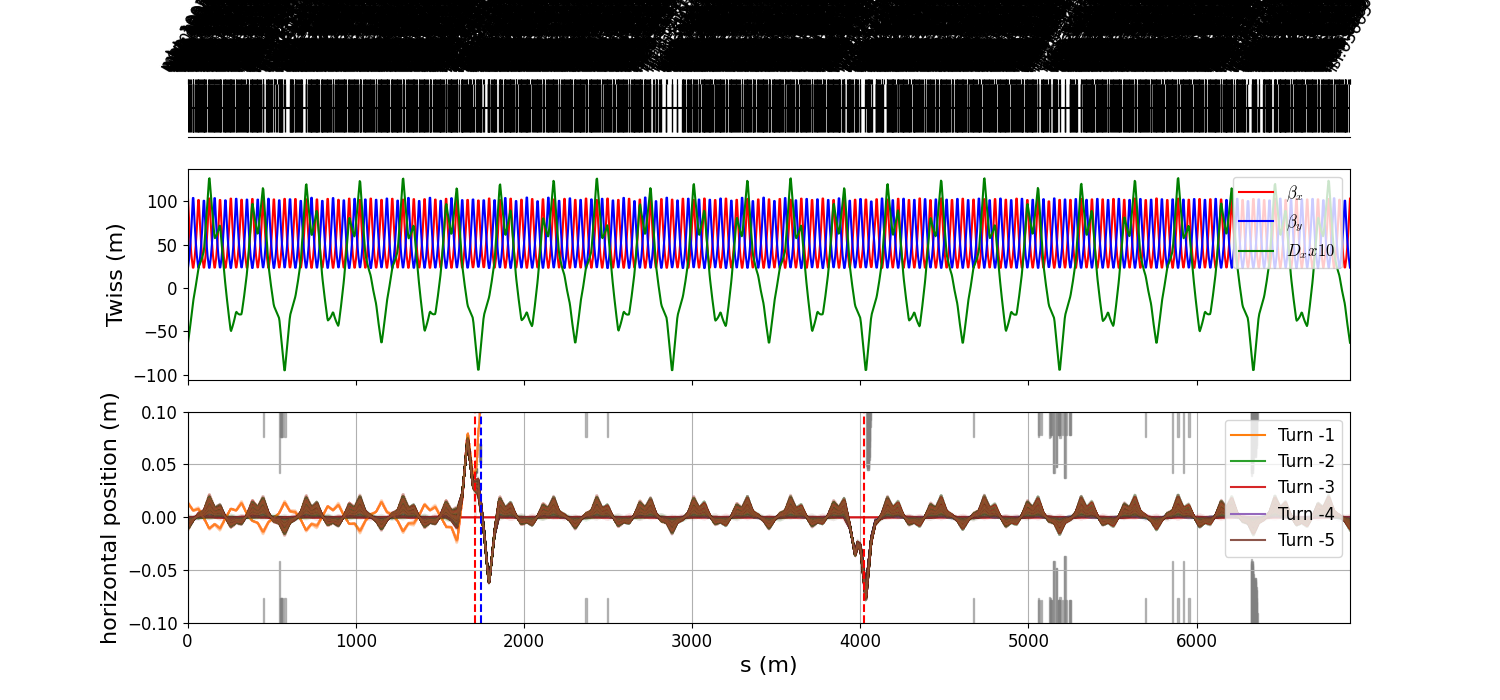

In [24]:
fig = plt.figure(figsize=(15,7))

plot_twiss(fig, tw_lss2, line)
fig.axes[2].grid(True)
fig.axes[2].set_xlabel('s (m)')
fig.axes[2].set_ylabel('horizontal position (m)')
fig.axes[2].set_ylim(-0.1, 0.1)

# plotting of the envelope
fig.axes[2].plot(tw_lss2.s, tw_lss2.x, 'r-')
#fig.axes[2].fill_between(tw_lss2.s, tw_lss2.x-sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), tw_lss2.x+sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), color='r', alpha=0.3, label='core envelope')



for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    fig.axes[2].add_patch(mpl.patches.Rectangle((s, x), 1, thickness, color='k', alpha=0.3))
    
# Insert rectangles for each element in df_elements
for _, row in df_elements.iterrows():
    color = 'grey'
    alpha = 0.5
    if row['Element Name'] in [elem[0] for elem in blocking_elements]:
        color = 'red'
        alpha = 1.0
    # Rectangle from min_x to bottom
    rect_min = plt.Rectangle((row['Position'], -0.25), width=8, height=row['min_x'] + 0.25, color=color, alpha=alpha)
    fig.axes[2].add_patch(rect_min)
    
    # Rectangle from max_x to top
    rect_max = plt.Rectangle((row['Position'], row['max_x']), width=8, height=0.25 - row['max_x'], color=color, alpha=alpha)
    fig.axes[2].add_patch(rect_max)
   
## PLOTTING TRAJECTORIES   
n_traj = 500

ax = fig.axes[2]
alpha = 10/n_traj
plot_only_lost = False
num_turns = 5

all_trajs = tw_lss2_df.apply(lambda row: row['monitors'].x, axis=1)
all_trajs = np.stack(all_trajs.values)

for ipart in np.random.randint(0, particles._capacity, size=n_traj):
    state = particles.state[ipart]
    if plot_only_lost and state > 0:
        print(f"Skipping particle {ipart} ")
        continue

    particle_id = particles.particle_id[ipart]
    el_lost = particles.at_element[ipart]
    traj = all_trajs[:, particle_id, :]
    # print(f"Particle {ipart} lost at {el_lost} with state {state} and id {particle_id} ")

    if state <= 0:
        # need to recontruct the turns since the particle was last
        s_lost = line.get_table()['s', line.element_names[el_lost]]
        row_lost = tw_lss2_df[abs(tw_lss2_df['s'] - s_lost) < 30e-3].iloc[0]
        i_lost = row_lost['i_monitor']+1

        traj_corr = np.nan * np.ones_like(traj)
        traj_corr[:i_lost, -1] = traj[:i_lost, -1]
        for iturn in range(2, num_turns+1):
            traj_corr[:, -iturn] = np.hstack([traj[:i_lost, -iturn-1], traj[i_lost:, -iturn]])
        traj = traj_corr

    for iturn in range(1, num_turns+1):
        ax.plot(tw_lss2_df['s'], traj[:, -iturn], color=plt.cm.tab10(iturn), alpha=alpha, ls='-') 
for iturn in range(1, num_turns+1):
    ax.plot([], [], color=plt.cm.tab10(iturn), label=f"Turn -{iturn}")
ax.legend(loc="upper right")

fig.axes[2].axvline(x=tpst_position, color='r', linestyle='--', label='TPST location')
fig.axes[2].axvline(x=line.get_table()['s', 'tt20.extraction'], color='b', linestyle='--', label='TT20')
fig.axes[2].axvline(x=teca_position, color='r', linestyle='--', label='TECA location')


In [25]:
for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    print(f"The element {element_name} at s = {s} m has the blade position at x = {x} m")

The element tpst.21760_entry.sep at s = 1712.220300000013 m has the blade position at x = 0.0394 m
The element mst.21774.sep at s = 1716.3533000000127 m has the blade position at x = 0.04079 m
The element mst.21779.sep at s = 1719.5873000000126 m has the blade position at x = 0.0424 m
The element mst.21794.sep at s = 1722.8213000000128 m has the blade position at x = 0.0424 m
The element mse.21832.sep at s = 1733.8060000000125 m has the blade position at x = 0.0527 m
The element mse.21837.sep at s = 1737.0400000000125 m has the blade position at x = 0.05184 m
The element mse.21852.sep at s = 1740.2740000000124 m has the blade position at x = 0.05184 m
The element mse.21857.sep at s = 1743.5080000000125 m has the blade position at x = 0.05184 m
The element mse.21872.sep at s = 1746.7420000000125 m has the blade position at x = 0.05184 m


# Plotting phase space at TECA

Text(0, 0.5, "$x'$ (mrad)")

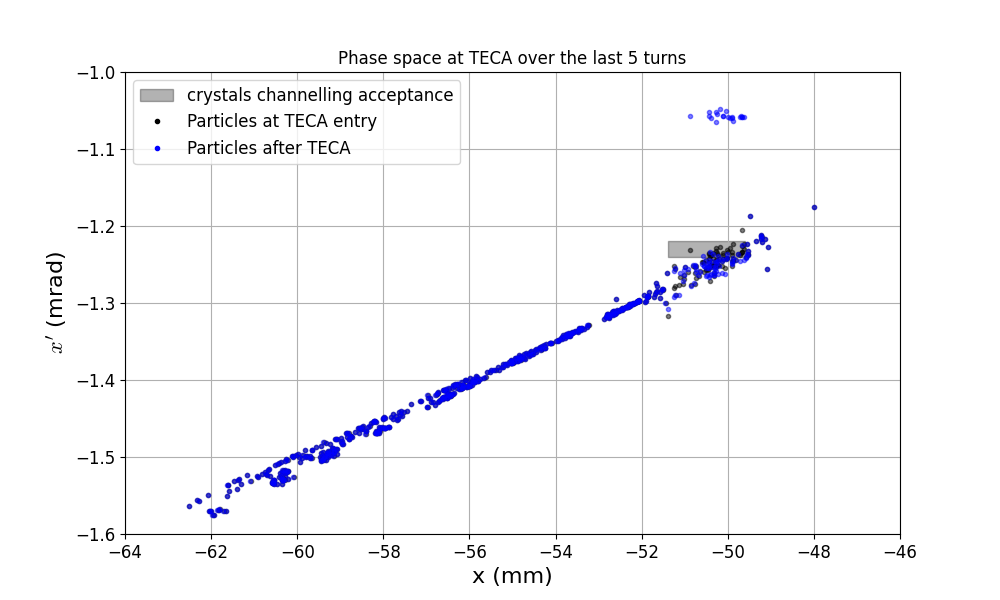

In [32]:
row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

#ax.plot(row_TECA_entry['monitors'].x[:, 5] * 1e3, row_TECA_entry['monitors'].px[:, 5] * 1e3, 'k.', alpha=0.5)  ## PLOTS ONLY THE PARTICLES AT THE LAST TURN
#ax.plot(row_TECA_exit['monitors'].x[:, 5] * 1e3, row_TECA_exit['monitors'].px[:, 5] * 1e3, 'b.', alpha=0.5)    ## PLOTS ONLY THE PARTICLES AT THE LAST TURN

ax.plot(row_TECA_entry['monitors'].x[:, :] * 1e3, row_TECA_entry['monitors'].px[:, :] * 1e3, 'k.', alpha= 0.5)  ## PLOTS  THE PARTICLES AT THE LAST 5 TURN
ax.plot(row_TECA_exit['monitors'].x[:, :] * 1e3, row_TECA_exit['monitors'].px[:, :] * 1e3, 'b.', alpha= 0.5)    ## PLOTS  THE PARTICLES AT THE LAST 5 TURN


ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')




ax.plot([], [], 'k.', label='Particles at TECA entry')
ax.plot([], [], 'b.', label='Particles after TECA')

ax.set_title("Phase space at TECA over the last 5 turns")
ax.legend()
ax.grid(True)

ax.set_xlim(-64, -46)
ax.set_ylim(-1.6, -1.0)

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

# Plotting phase space at TPST


Text(0, 0.5, "$x'$ (mrad)")

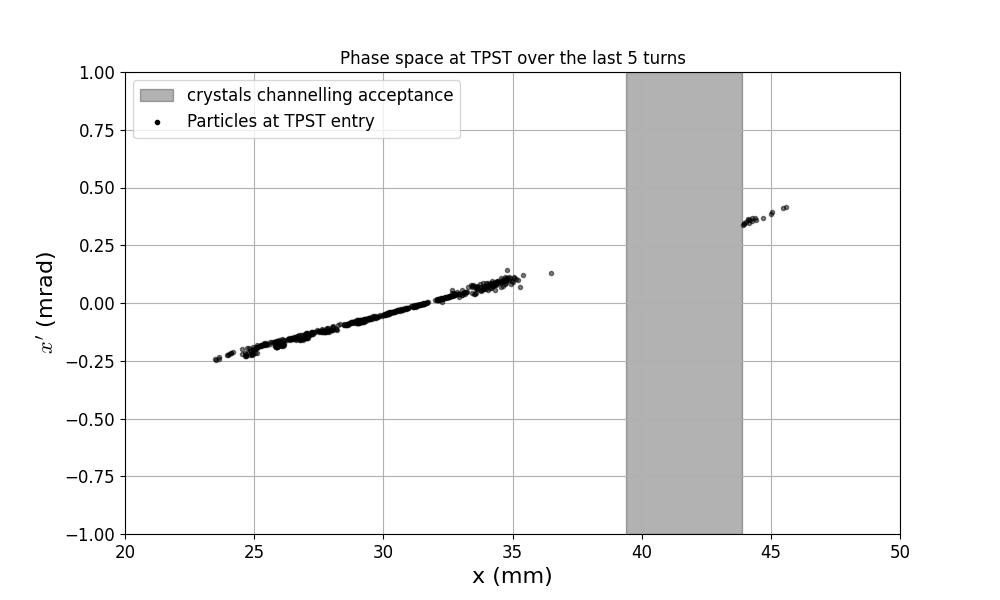

In [33]:
row_TPST_entry = tw_lss2_df.loc['tpst.21760_entry']


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(row_TPST_entry['monitors'].x[:, :] * 1e3, row_TPST_entry['monitors'].px[:, :] * 1e3, 'k.', alpha=0.5)

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
element_name = 'tpst.21760_entry.sep'
x = line[element_name].interaction_process.blade_position
thickness = line[element_name].interaction_process.thickness
ax.fill_between([x*1e3, x*1e3 + thickness*1e3],-1, 1, color='k', alpha=0.3, label='crystals channelling acceptance')



ax.plot([], [], 'k.', label='Particles at TPST entry')

ax.set_title("Phase space at TPST over the last 5 turns")

ax.legend()
ax.grid(True)

ax.set_xlim(20, 50)
ax.set_ylim(-1, 1)

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")